# 🩺 MediPath — MDP Chatbot Decision Engine for Healthcare
**Session III Lab Activity – MDP Exercises**

Goal: determine the optimal treatment plan for a patient based on their current health state.

1. Define states, actions, rewards, transition probabilities
2. Generate synthetic patient data and learn P, R from it
3. Policy iteration → optimal treatment policy (value iteration as cross-check)
4. Interpret outcomes critically (simulation, γ sensitivity)
5. MDP graph (same style as the class reference) + chatbot demo

In [1]:
!pip -q install graphviz
!apt-get -qq install -y graphviz > /dev/null

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 1. MDP engine (states, actions, P, R, data generator, policy iteration, triage, graphs)

In [2]:
"""
mdp_engine.py
Healthcare Treatment MDP - core engine for the chatbot decision engine.

States  : health condition of the patient   -> Healthy, Sick, Critical
Actions : treatment options                  -> No Treatment, Medication, Surgery
P[s][a] : probability of the next health state after one treatment cycle
R[s][a] : immediate reward = quality-of-life of current state - cost/risk of treatment

Pipeline: expert model -> synthetic patient records -> P, R estimated from data
          -> policy iteration (+ value iteration check) -> simulation -> graphs
"""
import numpy as np
import pandas as pd

# ---------------------------------------------------------------- 1. MDP components
states = ['Healthy', 'Sick', 'Critical']
actions = ['No Treatment', 'Medication', 'Surgery']

# Expert ("ground truth") transition model used to generate the synthetic hospital data.
# Reasoning behind the numbers:
#  - Healthy: doing nothing keeps you healthy; surgery on a healthy person adds risk.
#  - Sick: medication is the most effective; untreated illness can escalate.
#  - Critical: untreated critical patients rarely recover; surgery gives the best recovery odds.
TRUE_P = {
    'Healthy':  {'No Treatment': {'Healthy': 0.90, 'Sick': 0.08, 'Critical': 0.02},
                 'Medication':   {'Healthy': 0.92, 'Sick': 0.07, 'Critical': 0.01},
                 'Surgery':      {'Healthy': 0.80, 'Sick': 0.15, 'Critical': 0.05}},
    'Sick':     {'No Treatment': {'Healthy': 0.10, 'Sick': 0.60, 'Critical': 0.30},
                 'Medication':   {'Healthy': 0.60, 'Sick': 0.30, 'Critical': 0.10},
                 'Surgery':      {'Healthy': 0.50, 'Sick': 0.30, 'Critical': 0.20}},
    'Critical': {'No Treatment': {'Healthy': 0.00, 'Sick': 0.10, 'Critical': 0.90},
                 'Medication':   {'Healthy': 0.05, 'Sick': 0.35, 'Critical': 0.60},
                 'Surgery':      {'Healthy': 0.30, 'Sick': 0.45, 'Critical': 0.25}},
}

# Reward design: R(s, a) = quality of life in s  - treatment cost/risk of a
QUALITY_OF_LIFE = {'Healthy': 10, 'Sick': -2, 'Critical': -10}
TREATMENT_COST = {'No Treatment': 0, 'Medication': 2, 'Surgery': 8}
TRUE_R = {s: {a: QUALITY_OF_LIFE[s] - TREATMENT_COST[a] for a in actions} for s in states}

# How clinicians in the synthetic hospital choose treatments (behaviour policy).
# Every action has non-zero probability so every (state, action) pair appears in the data.
CLINICIAN_POLICY = {
    'Healthy':  {'No Treatment': 0.70, 'Medication': 0.25, 'Surgery': 0.05},
    'Sick':     {'No Treatment': 0.25, 'Medication': 0.55, 'Surgery': 0.20},
    'Critical': {'No Treatment': 0.15, 'Medication': 0.40, 'Surgery': 0.45},
}

# Typical vitals per state (mean, std) -> used for data + chatbot triage
VITALS = {
    'Healthy':  {'temperature': (36.8, 0.3), 'heart_rate': (72, 8),  'spo2': (98, 1.0), 'pain': (1, 1)},
    'Sick':     {'temperature': (38.2, 0.5), 'heart_rate': (95, 10), 'spo2': (95, 1.5), 'pain': (5, 1.5)},
    'Critical': {'temperature': (39.5, 0.7), 'heart_rate': (125, 12), 'spo2': (88, 3.0), 'pain': (8, 1.2)},
}


# ---------------------------------------------------------------- 2. Synthetic data
def generate_patient_data(n_patients=500, n_days=30, seed=42):
    """Simulate hospital records: one row = one treatment decision for one patient on one day."""
    rng = np.random.default_rng(seed)
    rows = []
    for pid in range(1, n_patients + 1):
        age = int(rng.integers(18, 90))
        state = rng.choice(states, p=[0.5, 0.35, 0.15])
        for day in range(1, n_days + 1):
            pol = CLINICIAN_POLICY[state]
            action = rng.choice(actions, p=list(pol.values()))
            probs = TRUE_P[state][action]
            next_state = rng.choice(list(probs.keys()), p=list(probs.values()))
            reward = TRUE_R[state][action] + rng.normal(0, 1.0)   # noisy observed outcome
            v = VITALS[state]
            rows.append({
                'patient_id': f'P{pid:04d}', 'day': day, 'age': age,
                'temperature': round(rng.normal(*v['temperature']), 1),
                'heart_rate': int(rng.normal(*v['heart_rate'])),
                'spo2': round(min(100, rng.normal(*v['spo2'])), 1),
                'pain_score': int(np.clip(rng.normal(*v['pain']), 0, 10)),
                'state': state, 'action': action, 'next_state': next_state,
                'treatment_cost': TREATMENT_COST[action], 'reward': round(reward, 2),
            })
            state = next_state
    return pd.DataFrame(rows)


def estimate_mdp_from_data(df):
    """Maximum-likelihood estimates: P = transition counts / visits, R = mean observed reward."""
    P, R = {}, {}
    for s in states:
        P[s], R[s] = {}, {}
        for a in actions:
            sub = df[(df.state == s) & (df.action == a)]
            counts = sub.next_state.value_counts()
            total = counts.sum()
            P[s][a] = {s2: float(round(counts.get(s2, 0) / total, 3)) for s2 in states} if total else dict(TRUE_P[s][a])
            R[s][a] = float(round(sub.reward.mean(), 2)) if total else TRUE_R[s][a]
    return P, R


# ---------------------------------------------------------------- 3. Policy iteration
def q_value(s, a, V, P, R, gamma):
    return sum(P[s][a].get(s2, 0) * (R[s][a] + gamma * V[s2]) for s2 in P[s][a])


def policy_evaluation(policy, P, R, gamma=0.9, theta=1e-6):
    V = {s: 0.0 for s in states}
    while True:
        delta = 0
        for s in states:
            v = V[s]
            V[s] = q_value(s, policy[s], V, P, R, gamma)
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            return V


def policy_iteration(P, R, gamma=0.9):
    """Returns optimal policy, state values and a history of each improvement step."""
    policy = {s: 'No Treatment' for s in states}   # deterministic start (reproducible)
    history = []
    while True:
        V = policy_evaluation(policy, P, R, gamma)
        history.append({'policy': dict(policy), 'V': {s: float(round(V[s], 2)) for s in states}})
        stable = True
        for s in states:
            old = policy[s]
            policy[s] = max(actions, key=lambda a: q_value(s, a, V, P, R, gamma))
            if old != policy[s]:
                stable = False
        if stable:
            return policy, {s: float(v) for s, v in V.items()}, history


def value_iteration(P, R, gamma=0.9, theta=1e-6):
    """Cross-check for policy iteration: both must give the same optimal policy."""
    V = {s: 0.0 for s in states}
    while True:
        delta = 0
        for s in states:
            v = V[s]
            V[s] = max(q_value(s, a, V, P, R, gamma) for a in actions)
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break
    policy = {s: max(actions, key=lambda a: q_value(s, a, V, P, R, gamma)) for s in states}
    return policy, {s: float(v) for s, v in V.items()}


def q_table(V, P, R, gamma=0.9):
    return pd.DataFrame({a: [q_value(s, a, V, P, R, gamma) for s in states] for a in actions}, index=states)


# ---------------------------------------------------------------- 4. Evaluate outcomes
def simulate_policy(policy, P, R, n_patients=2000, n_days=30, gamma=0.9, start='Sick', seed=7):
    """policy: dict state->action, or the string 'random'."""
    rng = np.random.default_rng(seed)
    ret, healthy_days, cost, end_critical = [], [], [], 0
    for _ in range(n_patients):
        s, G, h, c = start, 0.0, 0, 0
        for t in range(n_days):
            a = rng.choice(actions) if policy == 'random' else policy[s]
            G += (gamma ** t) * R[s][a]
            c += TREATMENT_COST[a]
            h += s == 'Healthy'
            nxt = P[s][a]
            s = rng.choice(list(nxt.keys()), p=np.array(list(nxt.values())) / sum(nxt.values()))
        ret.append(G); healthy_days.append(h); cost.append(c); end_critical += s == 'Critical'
    return {'avg_discounted_reward': np.mean(ret), 'pct_days_healthy': 100 * np.mean(healthy_days) / n_days,
            'avg_treatment_cost': np.mean(cost), 'pct_end_critical': 100 * end_critical / n_patients}


def compare_policies(optimal, P, R, gamma=0.9):
    candidates = {'Optimal (MDP)': optimal, 'Always No Treatment': {s: 'No Treatment' for s in states},
                  'Always Medication': {s: 'Medication' for s in states},
                  'Always Surgery': {s: 'Surgery' for s in states}, 'Random': 'random'}
    return pd.DataFrame({k: simulate_policy(v, P, R, gamma=gamma) for k, v in candidates.items()}).T.round(2)


def gamma_sensitivity(P, R, gammas=(0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99)):
    return pd.DataFrame({g: policy_iteration(P, R, g)[0] for g in gammas}).T.rename_axis('gamma')


# ---------------------------------------------------------------- 5. Chatbot triage
CRITICAL_WORDS = ['unconscious', 'chest pain', 'can\'t breathe', 'cannot breathe', 'difficulty breathing',
                  'seizure', 'bleeding heavily', 'stroke', 'collapsed', 'severe', 'fainted', 'blue lips']
SICK_WORDS = ['fever', 'cough', 'pain', 'headache', 'vomit', 'nausea', 'infection', 'flu', 'cold',
              'sore', 'dizzy', 'rash', 'diarrhea', 'tired', 'weak', 'sick', 'ill']
HEALTHY_WORDS = ['fine', 'healthy', 'checkup', 'check-up', 'good', 'normal', 'no symptoms', 'great']


def triage(text=None, temperature=None, heart_rate=None, spo2=None, pain=None):
    """Map symptoms/vitals to an MDP state. Returns (state, list of reasons)."""
    score, reasons = 0, []
    t = (text or '').lower()
    if any(w in t for w in CRITICAL_WORDS):
        score = max(score, 2); reasons.append('red-flag symptom mentioned')
    elif any(w in t for w in SICK_WORDS):
        score = max(score, 1); reasons.append('illness symptoms mentioned')
    if temperature is not None:
        if temperature >= 39.5 or temperature < 35: score = max(score, 2); reasons.append(f'temperature {temperature}°C')
        elif temperature >= 37.8: score = max(score, 1); reasons.append(f'fever {temperature}°C')
    if heart_rate is not None:
        if heart_rate >= 120 or heart_rate < 45: score = max(score, 2); reasons.append(f'heart rate {heart_rate} bpm')
        elif heart_rate >= 100: score = max(score, 1); reasons.append(f'elevated heart rate {heart_rate} bpm')
    if spo2 is not None:
        if spo2 < 92: score = max(score, 2); reasons.append(f'low oxygen {spo2}%')
        elif spo2 < 95: score = max(score, 1); reasons.append(f'borderline oxygen {spo2}%')
    if pain is not None:
        if pain >= 8: score = max(score, 2); reasons.append(f'severe pain {pain}/10')
        elif pain >= 4: score = max(score, 1); reasons.append(f'moderate pain {pain}/10')
    if not reasons:
        reasons.append('no warning signs found')
    return states[score], reasons


# ---------------------------------------------------------------- 6. Graphs
def build_reference_graph(P, R, hide_zero=True):
    """Same style as the class reference graph: edge label = 'action (prob), R: reward'."""
    from graphviz import Digraph
    dot = Digraph()
    for s in states:
        dot.node(s)
    for s in P:
        for a in P[s]:
            for s2, prob in P[s][a].items():
                if hide_zero and prob == 0:
                    continue
                dot.edge(s, s2, label=f"{a} ({prob}),    R: {R[s][a]}")
    return dot


ACTION_COLORS = {'No Treatment': '#7a8691', 'Medication': '#1f78b4', 'Surgery': '#c0392b'}
STATE_COLORS = {'Healthy': '#d5f5e3', 'Sick': '#fdebd0', 'Critical': '#fadbd8'}


def build_policy_graph(P, R, policy):
    """Readable version: colour per action, optimal-policy edges bold."""
    from graphviz import Digraph
    dot = Digraph(graph_attr={'rankdir': 'LR', 'label': 'Healthcare MDP - bold edges = optimal policy',
                              'labelloc': 't', 'fontsize': '16', 'nodesep': '0.8', 'ranksep': '1.6'})
    for s in states:
        dot.node(s, f"{s}\\n★ {policy[s]}", style='filled', fillcolor=STATE_COLORS[s], shape='ellipse', fontsize='13')
    for s in states:
        for a in actions:
            best = policy[s] == a
            for s2, prob in P[s][a].items():
                if prob == 0:
                    continue
                dot.edge(s, s2, label=f"{a} ({prob}) R:{R[s][a]}", color=ACTION_COLORS[a],
                         fontcolor=ACTION_COLORS[a], penwidth='3' if best else '0.8',
                         style='solid' if best else 'dashed', fontsize='9')
    return dot


## 2. Full pipeline: data → estimated P, R → policy iteration → evaluation → graphs

In [3]:
"""
run_pipeline.py - run the full healthcare MDP pipeline and save every output to ./outputs
Usage:  python run_pipeline.py
"""
import json, os
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUT = 'outputs'
os.makedirs(OUT, exist_ok=True)
GAMMA = 0.9
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 20)

# 1. Data
df = generate_patient_data()
df.to_csv(f'{OUT}/patient_data.csv', index=False)
print(f"Generated {len(df)} treatment records for {df.patient_id.nunique()} patients")

# 2. Estimate P and R from data
P, R = estimate_mdp_from_data(df)
json.dump({'P': P, 'R': R}, open(f'{OUT}/mdp_model.json', 'w'), indent=2)
print("\nEstimated transition probabilities P:")
for s in states:
    for a in actions:
        print(f"  {s:8s} + {a:12s} -> {P[s][a]}")
print("\nEstimated rewards R:\n", pd.DataFrame(R).T)

# 3. Policy iteration (+ value iteration check)
policy, V, history = policy_iteration(P, R, GAMMA)
vi_policy, vi_V = value_iteration(P, R, GAMMA)
print("\nPolicy iteration steps:")
for i, h in enumerate(history):
    print(f"  iter {i}: {h['policy']}  V={h['V']}")
print("\nOptimal Policy (policy iteration):", policy)
print("State Values:", {s: round(v, 2) for s, v in V.items()})
print("Optimal Policy (value iteration): ", vi_policy)
print("Both methods agree:", policy == vi_policy)

Q = q_table(V, P, R, GAMMA)
print("\nQ-values (expected long-term reward of each treatment):\n", Q.round(2))

# 4. Outcome analysis
cmp = compare_policies(policy, P, R, GAMMA)
print("\nPolicy comparison (2000 simulated sick patients, 30 days):\n", cmp)
sens = gamma_sensitivity(P, R)
print("\nDiscount factor sensitivity:\n", sens)

# 5. Graphs
build_reference_graph(P, R).render(f'{OUT}/mdp_flowchart', format='png', cleanup=True)
build_policy_graph(P, R, policy).render(f'{OUT}/mdp_policy_graph', format='png', cleanup=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
cmp['avg_discounted_reward'].plot.barh(ax=axes[0], color=['#27ae60'] + ['#95a5a6'] * 4, title='Avg discounted reward (higher = better)')
cmp['pct_days_healthy'].plot.barh(ax=axes[1], color=['#27ae60'] + ['#95a5a6'] * 4, title='% of days healthy')
cmp['pct_end_critical'].plot.barh(ax=axes[2], color=['#27ae60'] + ['#95a5a6'] * 4, title='% ending in Critical (lower = better)')
for ax in axes: ax.invert_yaxis()
plt.tight_layout(); plt.savefig(f'{OUT}/policy_comparison.png', dpi=130); plt.close()

fig, ax = plt.subplots(figsize=(7, 4))
Q.plot.bar(ax=ax, color=[ACTION_COLORS[a] for a in actions], rot=0, title='Q-values per state and treatment')
ax.axhline(0, color='k', lw=0.6); ax.set_ylabel('Expected discounted reward')
plt.tight_layout(); plt.savefig(f'{OUT}/q_values.png', dpi=130); plt.close()

# 6. Text report
with open(f'{OUT}/results.txt', 'w') as f:
    f.write(f"OPTIMAL TREATMENT POLICY (gamma={GAMMA})\n{policy}\n\nSTATE VALUES\n{V}\n\n")
    f.write(f"Q-VALUES\n{Q.round(2)}\n\nPOLICY COMPARISON\n{cmp}\n\nGAMMA SENSITIVITY\n{sens}\n")
print(f"\nAll outputs saved in ./{OUT}/")


Generated 15000 treatment records for 500 patients

Estimated transition probabilities P:
  Healthy  + No Treatment -> {'Healthy': 0.9, 'Sick': 0.081, 'Critical': 0.02}
  Healthy  + Medication   -> {'Healthy': 0.918, 'Sick': 0.07, 'Critical': 0.011}
  Healthy  + Surgery      -> {'Healthy': 0.826, 'Sick': 0.113, 'Critical': 0.061}
  Sick     + No Treatment -> {'Healthy': 0.1, 'Sick': 0.6, 'Critical': 0.299}
  Sick     + Medication   -> {'Healthy': 0.593, 'Sick': 0.281, 'Critical': 0.126}
  Sick     + Surgery      -> {'Healthy': 0.482, 'Sick': 0.281, 'Critical': 0.237}
  Critical + No Treatment -> {'Healthy': 0.0, 'Sick': 0.098, 'Critical': 0.902}
  Critical + Medication   -> {'Healthy': 0.044, 'Sick': 0.383, 'Critical': 0.573}
  Critical + Surgery      -> {'Healthy': 0.281, 'Sick': 0.437, 'Critical': 0.282}

Estimated rewards R:
           No Treatment  Medication  Surgery
Healthy          10.00        8.00     1.96
Sick             -2.03       -4.02   -10.01
Critical         -9.93     


Policy comparison (2000 simulated sick patients, 30 days):
                      avg_discounted_reward  pct_days_healthy  avg_treatment_cost  pct_end_critical
Optimal (MDP)                        49.00             79.06               21.32              4.75
Always No Treatment                 -39.20             17.67                0.00             62.75
Always Medication                    36.59             78.83               60.00              6.10
Always Surgery                      -38.01             66.05              240.00             11.75
Random                                0.54             63.98              100.76             14.85

Discount factor sensitivity:
             Healthy          Sick      Critical
gamma                                          
0.10   No Treatment  No Treatment  No Treatment
0.30   No Treatment    Medication  No Treatment
0.50   No Treatment    Medication    Medication
0.70   No Treatment    Medication       Surgery
0.90   No Treatment    Med


All outputs saved in ./outputs/


## 3. MDP flowchart (reference style: `action (probability), R: reward`)

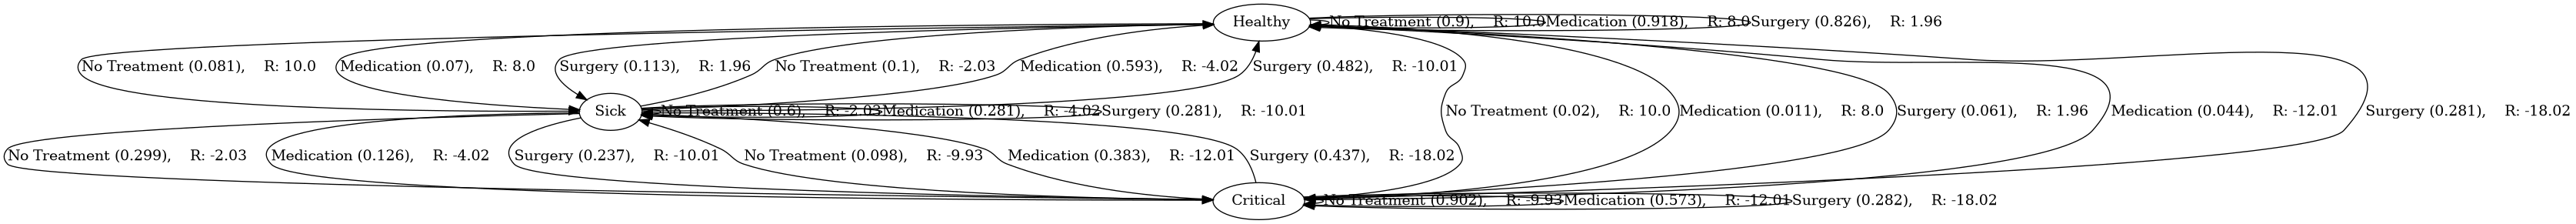

In [4]:
from IPython.display import Image, display
display(Image('outputs/mdp_flowchart.png'))

## 4. Optimal-policy graph (bold = optimal action)

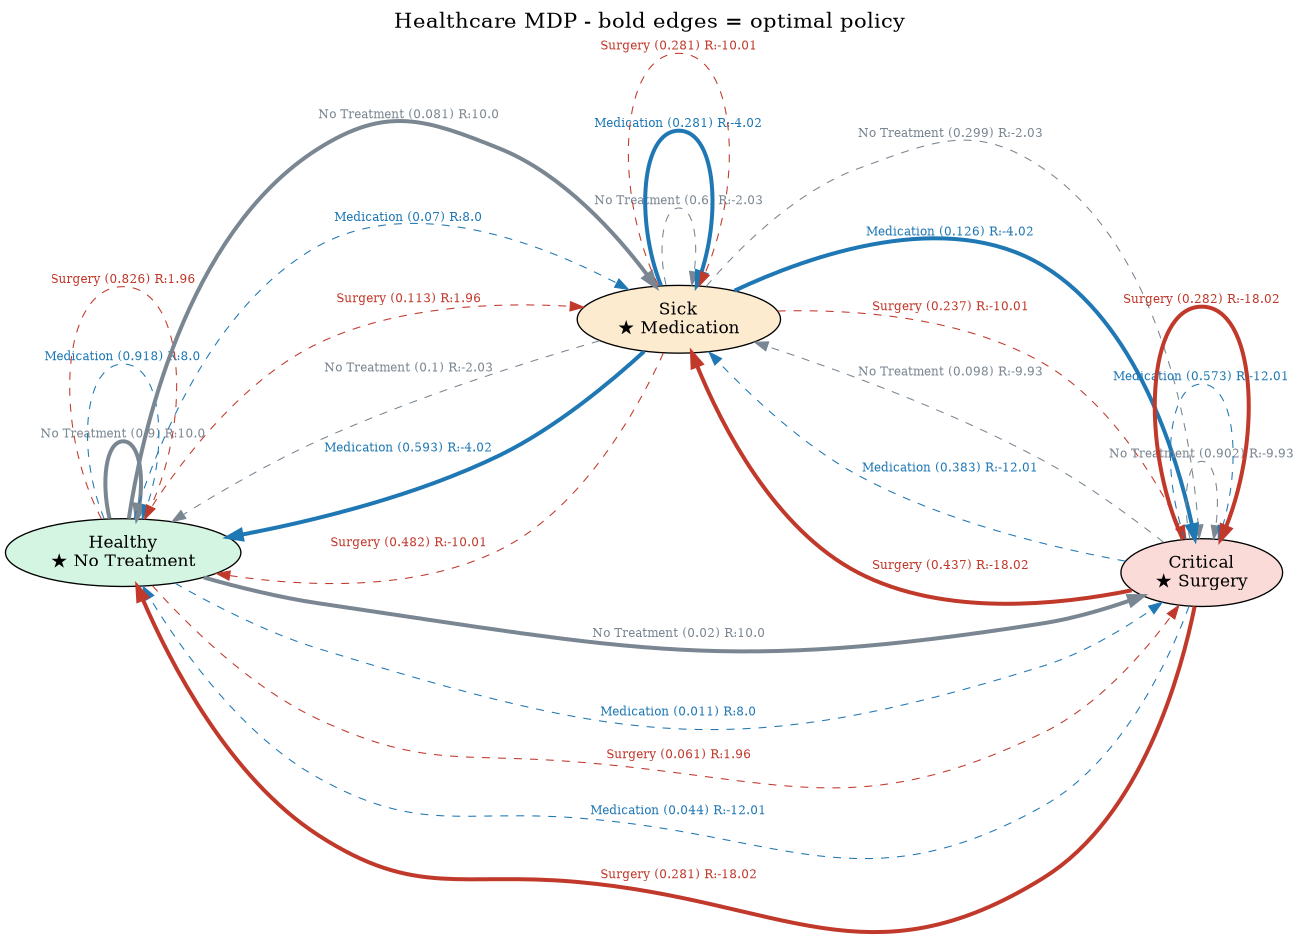

In [5]:
display(Image('outputs/mdp_policy_graph.png'))

## 5. Outcome analysis

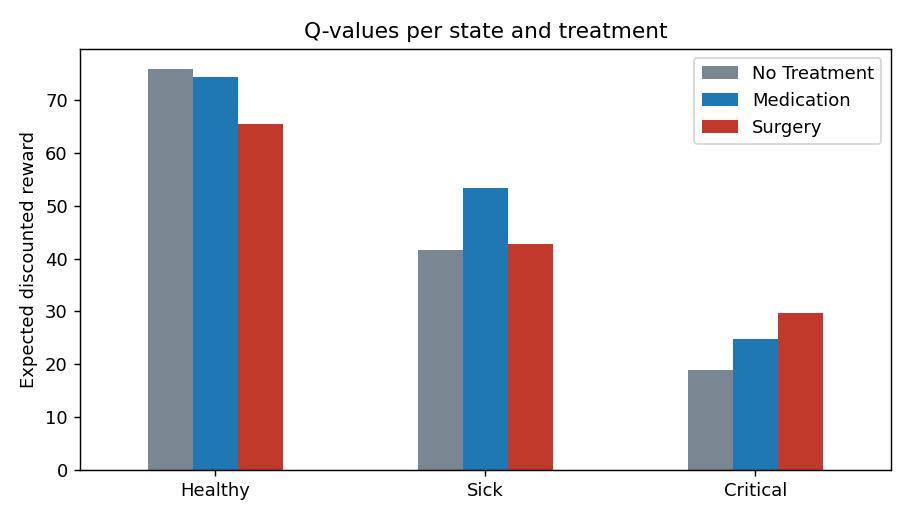

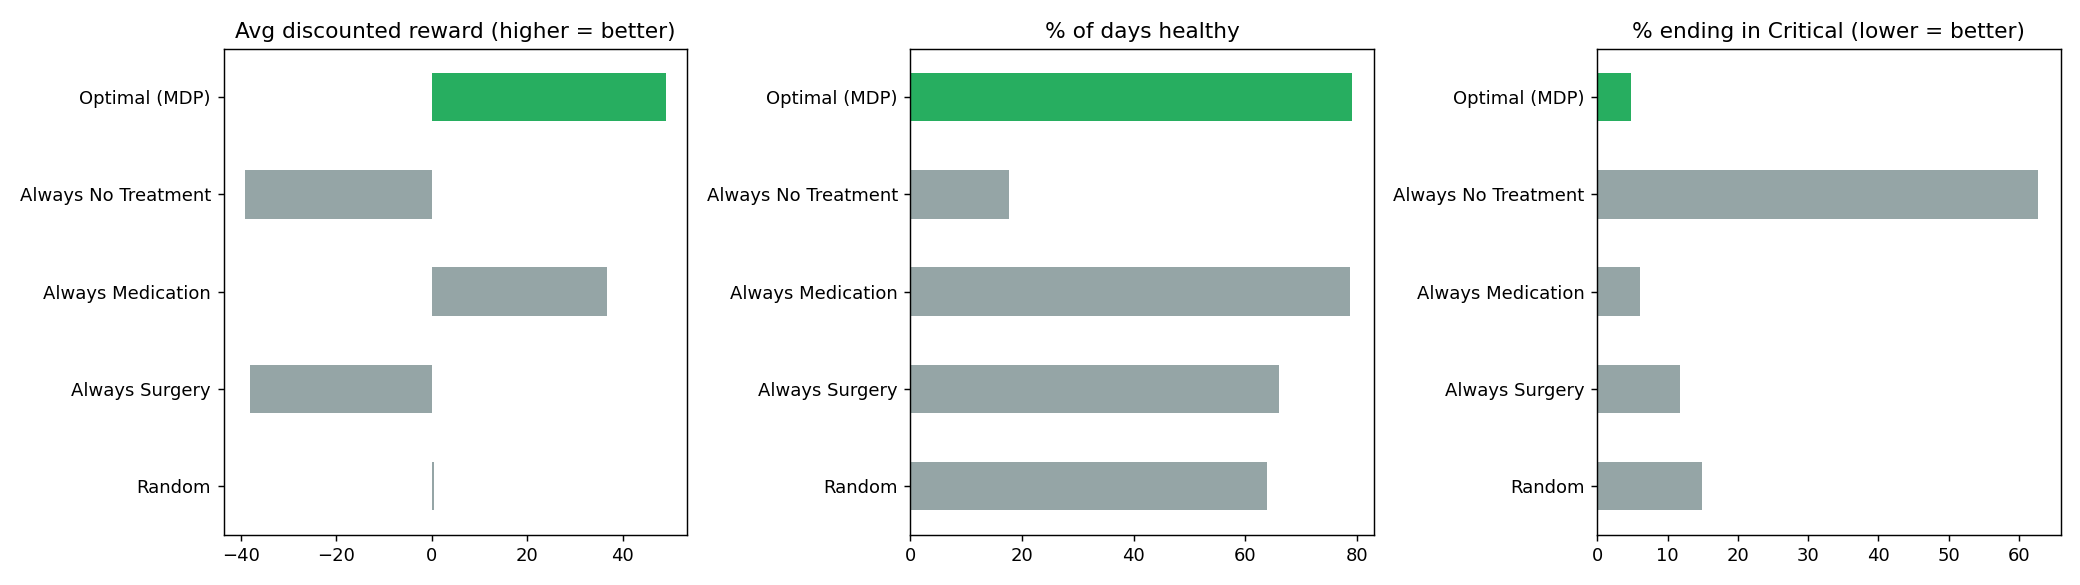

In [6]:
display(Image('outputs/q_values.png'))
display(Image('outputs/policy_comparison.png'))

## 6. Chatbot demo

In [7]:
def chatbot(message, **vitals):
    s, why = triage(text=message, **vitals)
    a = policy[s]
    print(f'👤 {message} {vitals if vitals else ""}')
    print(f'🤖 State: {s} ({", ".join(why)}) -> Recommended: {a}')
    print('   Next-state odds:', {k: f"{p*100:.0f}%" for k, p in P[s][a].items()}, '\n')

chatbot('Feeling fine, just a routine checkup')
chatbot('I have a fever and a cough', temperature=38.4)
chatbot('Severe chest pain', heart_rate=130, spo2=88)

👤 Feeling fine, just a routine checkup 
🤖 State: Healthy (no warning signs found) -> Recommended: No Treatment
   Next-state odds: {'Healthy': '90%', 'Sick': '8%', 'Critical': '2%'} 

👤 I have a fever and a cough {'temperature': 38.4}
🤖 State: Sick (illness symptoms mentioned, fever 38.4°C) -> Recommended: Medication
   Next-state odds: {'Healthy': '59%', 'Sick': '28%', 'Critical': '13%'} 

👤 Severe chest pain {'heart_rate': 130, 'spo2': 88}
🤖 State: Critical (red-flag symptom mentioned, heart rate 130 bpm, low oxygen 88%) -> Recommended: Surgery
   Next-state odds: {'Healthy': '28%', 'Sick': '44%', 'Critical': '28%'} 



## 7. Interpretation (critical thinking)
- **Optimal policy (γ=0.9): Healthy → No Treatment, Sick → Medication, Critical → Surgery.** It matches clinical intuition: don't over-treat healthy patients, medicate illness, escalate only when critical.
- **Policy vs. baselines:** the MDP policy keeps ~79% of days healthy — same as *always medicate* — but at roughly a third of the treatment cost, and far fewer patients end up critical than with no treatment, always-surgery or random care.
- **γ matters:** with a short-sighted γ (0.1) the engine recommends *no treatment everywhere* because treatment costs are immediate while benefits come later. Surgery for critical patients only becomes optimal at γ ≥ ~0.7. In healthcare, a high γ is the right choice.
- **Policy iteration and value iteration agree**, which validates the implementation. (Note: in the class notebook `value_iteration()` was defined but never called, so it only reprinted the policy-iteration result.)
- **Limitations:** 3 coarse states, no death/terminal state, reward weights are design choices (changing surgery cost can change the policy), data is synthetic, the Markov assumption ignores patient history, age and comorbidities. Next steps: add a terminal *Deceased* state, age-stratified models, POMDP for uncertain diagnoses, and real clinical data.